In [285]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, exp, conj, min, argmin, unravel_index

In [287]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind
def hl1_asymptotic(n, z):
    #return sqrt(2/(pi*z))*np.exp(1j*(z-pi/4))*(-1j)**n
    return sqrt(1/(pi*z))*(1-1j)*exp(1j*z)*(-1j)**n
def hl2_asymptotic(n, z):
    return conj(hl1_asymptotic(n, z))

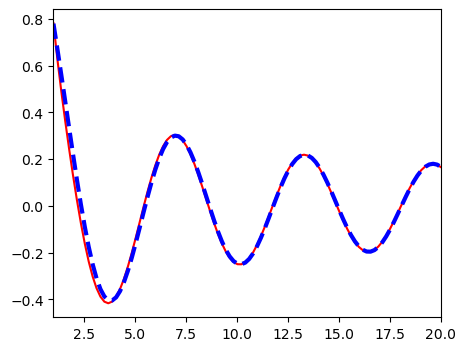

In [288]:
x = linspace(1, 20, 100, endpoint=True)
hankel_exact = hankel2(1, x)
hankel_approximate = hl2_asymptotic(1, x)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, hankel_exact.imag, color="red")
ax.plot(x, hankel_approximate.imag, linestyle="dashed", linewidth=3, color="blue")
ax.set_xlim(1, 20);

### Coherent perfect absorption through finite surface impedance (large kR first)

In [290]:
M = 10000
epsilon = 2
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))
Z_s = -1 # Impedance of the surface layer (minus inverse of surface conductivity) in units of 1/c*epsilon_0
x = linspace(100, 200, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
    rhs_num =  jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl2_prime(l, x)

    lhs_denom =  jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_odd_array[l_indx, :] = abs(s)**2
    
n = 3
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
    rhs_num =  jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl2_prime(l, x)

    lhs_denom =  jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_even_array[l_indx, :] = abs(s)**2

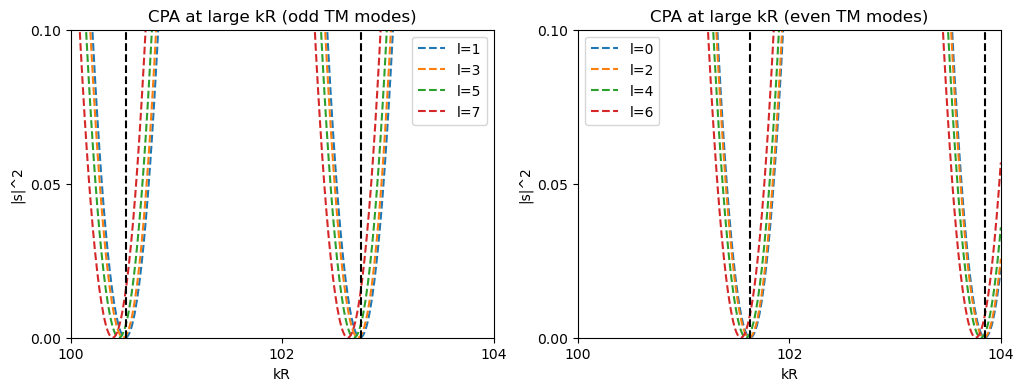

In [291]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")

ax1.vlines([pi/4/sqrt(epsilon)]+ pi * linspace(1, 300, 300)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(100, 104)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xticks([100, 102, 104])
ax1.set_title("CPA at large kR (odd TM modes)")
ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.vlines([-pi/4/sqrt(epsilon)]+ pi * linspace(1, 300, 300)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax2.set_xlim(100, 104)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xticks([100, 102, 104])
ax2.set_title("CPA at large kR (even TM modes)")
ax2.set_xlabel("kR");
ax2.legend();
ax2.set_ylabel("|s|^2");

### Now we do the same for TE modes

In [292]:
M = 10000
epsilon = 2
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))
Z_s = -1 ## Impedance of the surface layer in units of 1/c*epsilon_0
x = linspace(100, 200, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    lhs_num =  jv(l, y) * hl2_prime(l, x)
    rhs_num =  sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel2(l, x) 

    lhs_denom = jv(l, y) * hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel1(l, x) 
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_odd_array[l_indx, :] = abs(s)**2
    
n = 3
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    lhs_num =  jv(l, y) * hl2_prime(l, x)
    rhs_num =  sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel2(l, x) 

    lhs_denom = jv(l, y) * hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel1(l, x) 
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_even_array[l_indx, :] = abs(s)**2

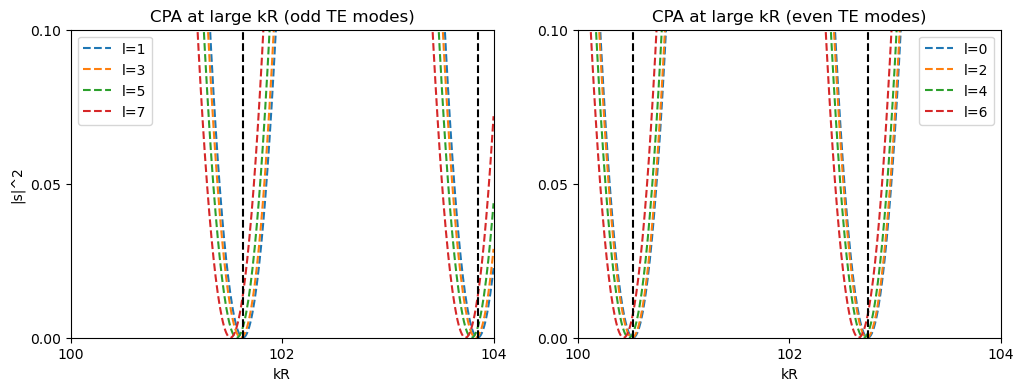

In [294]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")

ax1.vlines([-pi/4/sqrt(epsilon)]+ pi * linspace(1, 300, 300)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(100, 104)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xticks([100, 102, 104])

ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()
ax1.set_title("CPA at large kR (odd TE modes)")

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.vlines([pi/4/sqrt(epsilon)]+ pi * linspace(1, 300, 300)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax2.set_xlim(100, 104)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xticks([100, 102, 104])

ax2.set_xlabel("kR");
ax2.legend();
#ax2.set_ylabel("|s|^2");
ax2.set_title("CPA at large kR (even TE modes)");

### Now we look at subwavelength

### Note that the TM plasmon dispersion in the quasistatic limit obeys $(1+\varepsilon_m)x/m = -i\sigma(\omega)/c\varepsilon_0$. In the below, we define $g(\omega)=i/Z_sc\varepsilon_0=-i\sigma(\omega)/c\varepsilon_0$

In [296]:
epsilon_real = 1
l = 1

M = 1000
N = 5000
g_omega_center = x*(1+epsilon_real)/l # corresponds to quasistatic plasmon 
g_omegas = linspace(0.202, 0.203, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.014, 0.016, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [297]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - g_omegas*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + g_omegas*jvp(l, y, 1)*hl1_prime(l, x) - sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [298]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  2.3215061964432818e-08


In [299]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [300]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

CPA imepsilon:  0.015930786157231445  and CPA g(omega):  0.2026716716716717


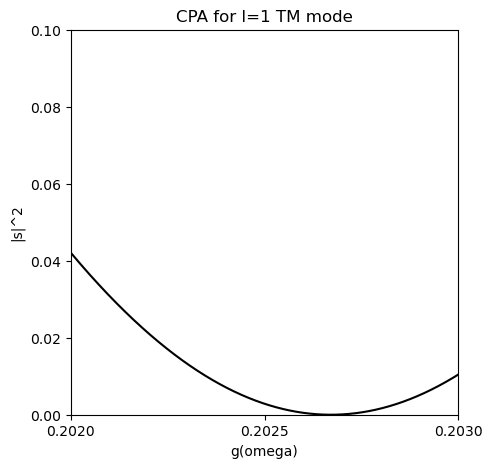

In [301]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TM mode");

In [302]:
epsilon_real = 12
l = 2
M = 1000
N = 5000
g_omegas = linspace(0.6562027927927928-1e-7, 0.6562027927927928+1e-7, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.000019, 0.000020, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder
g_omega_center = x*(1+epsilon_real)/l;

In [303]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - g_omegas*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + g_omegas*jvp(l, y, 1)*hl1_prime(l, x)-sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [304]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  2.0401244383625403e-09


In [305]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [306]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

CPA imepsilon:  1.9243448689737947e-05  and CPA g(omega):  0.6562027958958959


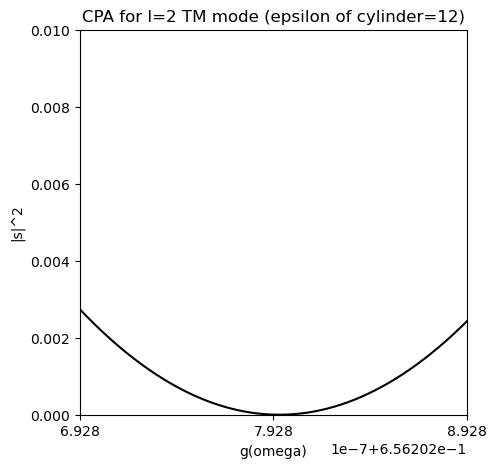

In [307]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.01)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TM mode (epsilon of cylinder=12)");

### Now we do the same for TE modes for $l=1,2$

### From the TE plasmon dispersion, we expect $Z_s\approx -ix/2nc\varepsilon_0$

In [310]:
epsilon_real = 1
l = 1

M = 2000
N = 2000
Z_s_arr = -linspace(0.049, 0.052, M).reshape((M, 1)).repeat(N, 1)*1j
epsilon_imaginary = linspace(5.9, 6.2, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [311]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [312]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  6.681371720574345e-08


In [313]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [314]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", Z_s_arr[idxs])

CPA imepsilon:  6.098549274637319  and CPA g(omega):  (-0-0.05066733366683342j)


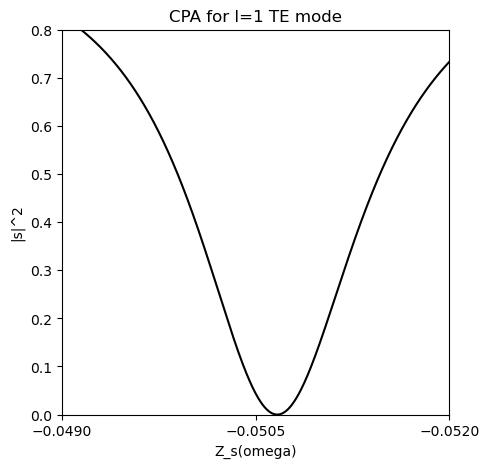

In [315]:
x1 = Z_s_arr[0, idxs[1]]/1j
x2 = Z_s_arr[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.8)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TE mode");

In [316]:
epsilon_real = 12
l = 2

M = 2000
N = 2000
Z_s_arr = -linspace(0.025157, 0.025159, M).reshape((M, 1)).repeat(N, 1)*1j
epsilon_imaginary = linspace(0.0233, 0.0234, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [317]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [318]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  4.348695828801877e-07


In [319]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [320]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", Z_s_arr[idxs])

CPA imepsilon:  0.02332631315657829  and CPA g(omega):  (-0-0.025157930465232615j)


### Note that the best value for $Z_s$ is indeed approximately $Z_s\approx -i/(2\times n \times x)=-i/(2\times 2\times 0.1)$

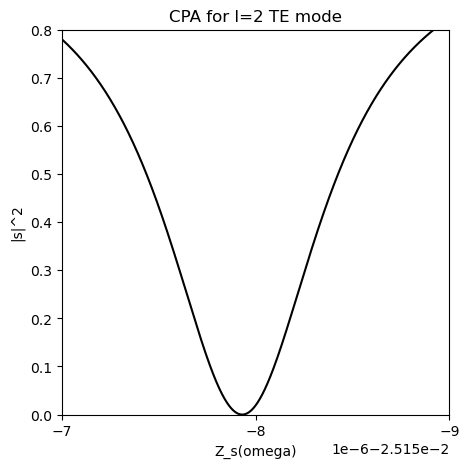

In [322]:
x1 = Z_s_arr[0, idxs[1]]/1j
x2 = Z_s_arr[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.8)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TE mode");